# Quaternion PMD Compensation Results

This notebook compares quaternion-based PMD compensation algorithms (NLMS and Kalman) using the `QuaternionPMDChannel` within the `quantum-comm-sim` framework. 
Academic References:
  - Alnaseri, Omar, et al. "Fading-Memory Quaternion-Based Kalman Filter for Quantum Channel PMD Compensation." IEEE Access (2026).


In [ ]:
import importlib
import os
import numpy as np
import matplotlib.pyplot as plt
from quantum_comm_sim.channels.quaternion_pmd_channel import QuaternionPMDChannel
import quantum_comm_sim.equalization.quaternion_pmd_equalizer as quaternion_pmd_equalizer

quaternion_pmd_equalizer = importlib.reload(quaternion_pmd_equalizer)
QuaternionNLMS = quaternion_pmd_equalizer.QuaternionNLMS
QuaternionKalmanBaseline = quaternion_pmd_equalizer.QuaternionKalmanBaseline
TrueQuaternionLMS = quaternion_pmd_equalizer.TrueQuaternionLMS
TrueQuaternionRLS = quaternion_pmd_equalizer.TrueQuaternionRLS
QuaternionMEKF = quaternion_pmd_equalizer.QuaternionMEKF
FMQuaternionMEKF = quaternion_pmd_equalizer.FMQuaternionMEKF
compute_broadband_fidelity = quaternion_pmd_equalizer.compute_broadband_fidelity

results_root = '../results'
DATA_DIR = os.path.join(results_root, 'data')
FIG_DIR = os.path.join(results_root, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


In [13]:
# Simulation configuration
NUM_FREQ = 5
BANDWIDTH_NM = 40
MAX_ITER = 500
NUM_RUNS = 50
FIBER_LENGTH_KM = 50.0

# Frequency grid (re-using pattern from original notebook)
lambda_0 = 1550e-9
c = 3e8
f_0 = c / lambda_0
delta_lambda = BANDWIDTH_NM * 1e-9 / NUM_FREQ
delta_f = c * delta_lambda / (lambda_0**2)
omega_grid = 2 * np.pi * np.linspace(
    f_0 - delta_f * (NUM_FREQ//2),
    f_0 + delta_f * (NUM_FREQ//2),
    NUM_FREQ
)

# Target quaternion (identity) and spectral weights
q_target = np.array([[1.0], [0.0], [0.0], [0.0]])
spectral_weights = np.ones(NUM_FREQ) / NUM_FREQ


In [14]:
# Helper: construct algorithm instances and run one Monte Carlo simulation
def create_algorithm(label):
    if label == 'qlms':
        return TrueQuaternionLMS(num_freq=NUM_FREQ)
    if label == 'qrls':
        return TrueQuaternionRLS(num_freq=NUM_FREQ)
    if label == 'qmekf':
        return QuaternionMEKF(numfreq=NUM_FREQ)
    if label == 'fm_qmekf':
        return FMQuaternionMEKF(
            numfreq=NUM_FREQ,
            fast_bins=list(range(NUM_FREQ)),
            fast_factor=10.0,
        )
    raise ValueError(f'Unknown algorithm label: {label}')


def adapt_algorithm(alg, state_vec, target_tile):
    if isinstance(alg, (TrueQuaternionLMS, TrueQuaternionRLS)):
        alg.adapt(state_vec, target_tile, spectral_weights=spectral_weights)
    else:
        alg.adapt(state_vec, target_tile, spectralweights=spectral_weights)


def run_algorithm(make_algorithm, label):
    mse_runs = []
    fid_runs = []
    for run in range(NUM_RUNS):
        channel = QuaternionPMDChannel(fiber_length_km=FIBER_LENGTH_KM)
        alg = make_algorithm()
        mse_hist = []
        fid_hist = []
        for it in range(MAX_ITER):
            channel.update(it)
            state_vec = np.zeros((4, NUM_FREQ))
            for idx, omega in enumerate(omega_grid):
                q = channel.get_state(omega)
                state_vec[:, idx] = q.to_array()
            target_tile = np.tile(q_target, (1, NUM_FREQ))
            adapt_algorithm(alg, state_vec, target_tile)
            mse_hist.append(alg.mse_history[-1])
            fid_hist.append(alg.spectral_fidelity_history[-1])
        mse_runs.append(mse_hist)
        fid_runs.append(fid_hist)
    mse_runs = np.array(mse_runs)
    fid_runs = np.array(fid_runs)
    np.save(os.path.join(DATA_DIR, f'mse_{label}.npy'), mse_runs)
    np.save(os.path.join(DATA_DIR, f'fid_{label}.npy'), fid_runs)
    return mse_runs, fid_runs

In [15]:
# Run selected algorithms: QLMS, QRLS, MEKF, FM-MEKF
algorithm_factories = {
    'qlms': lambda: create_algorithm('qlms'),
    'qrls': lambda: create_algorithm('qrls'),
    'qmekf': lambda: create_algorithm('qmekf'),
    'fm_qmekf': lambda: create_algorithm('fm_qmekf'),
}

all_stats = {}
for label, make_algorithm in algorithm_factories.items():
    print(f'Running {label} ...')
    mse_runs, fid_runs = run_algorithm(make_algorithm, label)
    mse_mean = mse_runs.mean(axis=0)
    fid_mean = fid_runs.mean(axis=0)
    all_stats[label] = {'mse_mean': mse_mean, 'fid_mean': fid_mean}

Running qlms ...
Running qrls ...
Running qmekf ...
Running fm_qmekf ...


'../results\\figures\\quaternion_pmd_mse_comparison.png'

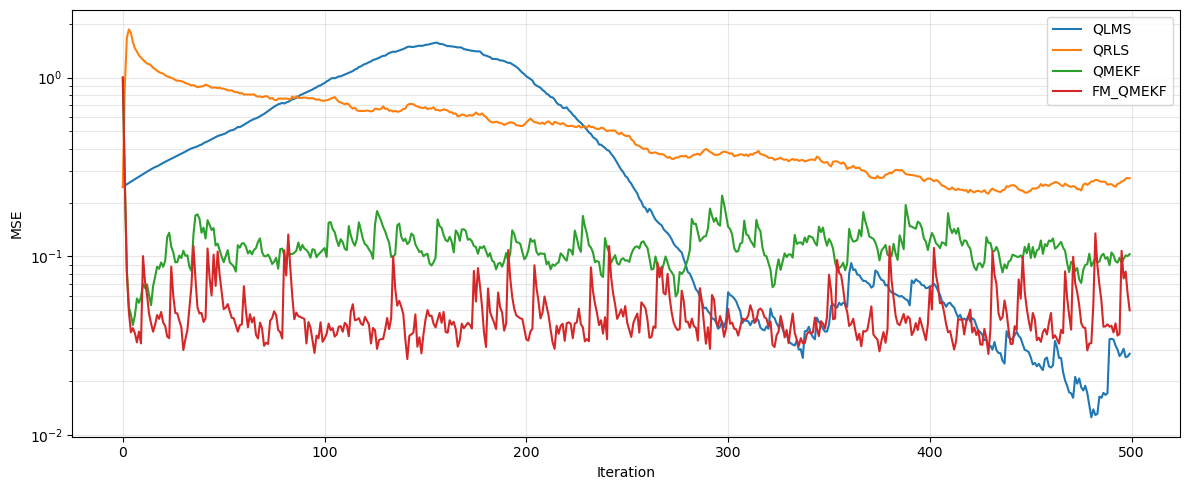

In [18]:
# Visualization
plt.figure(figsize=(12,5))
for label, color in [('qlms','tab:blue'), ('qrls','tab:orange'), ('qmekf','tab:green'), ('fm_qmekf','tab:red')]:
    plt.semilogy(all_stats[label]['mse_mean'], label=label.upper(), color=color)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'quaternion_pmd_mse_comparison.png')
plt.savefig(fig_path, dpi=300)
fig_path
